In [3]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset


In [4]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.56MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 161kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]


In [5]:
train_idx = [
    i for i, (_, label) in enumerate(train_dataset)
    if label in [0, 1]
]

test_idx = [
    i for i, (_, label) in enumerate(test_dataset)
    if label in [0, 1]
]

In [6]:
train_dataset = Subset(train_dataset, train_idx)
test_dataset = Subset(test_dataset, test_idx)

In [7]:
print(len(train_dataset))
print(len(test_dataset))

12665
2115


In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [11]:
import torch.nn as nn

class DigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.network(x)

In [13]:
model = DigitClassifier()

print(model)

DigitClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [14]:
criterion = nn.BCEWithLogitsLoss()

In [15]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [22]:
epochs = 10
for epoch in range(epochs):
    model.train()

    running_loss = 0
    for images, labels in train_loader:

        images = images

        labels = labels.float().unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}"
    )

Epoch 1/10, Loss: 0.0000
Epoch 2/10, Loss: 0.0000
Epoch 3/10, Loss: 0.0001
Epoch 4/10, Loss: 0.0000
Epoch 5/10, Loss: 0.0000
Epoch 6/10, Loss: 0.0000
Epoch 7/10, Loss: 0.0000
Epoch 8/10, Loss: 0.0000
Epoch 9/10, Loss: 0.0000
Epoch 10/10, Loss: 0.0000


In [18]:
labels.float().unsqueeze(1)

tensor([[[1.]],

        [[0.]],

        [[0.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[0.]],

        [[0.]],

        [[1.]],

        [[1.]],

        [[0.]],

        [[0.]],

        [[0.]],

        [[1.]],

        [[0.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[0.]],

        [[0.]],

        [[0.]],

        [[0.]],

        [[0.]],

        [[0.]],

        [[1.]],

        [[1.]],

        [[0.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[0.]],

        [[1.]],

        [[0.]],

        [[1.]],

        [[0.]],

        [[0.]],

        [[1.]],

        [[0.]],

        [[1.]],

        [[0.]],

        [[0.]],

        [[0.]],

        [[1.]],

        [[0.]],

        [[0.]],

        [[1.]],

        [[0.]],

        [[1.]],

        [[1.]],

        [[0.]],

        [[0.]],

        [[0.]],

        [[1.]]])

In [21]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        predictions = (torch.sigmoid(outputs) > 0.5).float()

        correct += (predictions.squeeze() == labels).sum().item()

        total += labels.size(0)

accuracy = 100 * correct / total

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 99.95%


In [23]:
torch.save(model.state_dict(), "digit_classifier.pth")

In [24]:
import os

print(os.path.exists("digit_classifier.pth"))

True


In [25]:
model.eval()
images, labels = next(iter(test_loader))

In [26]:
outputs = model(images)

predictions = (torch.sigmoid(outputs) > 0.5).float()

for i in range(10):
    print(
        f"Actual: {int(labels[i])} | Predicted: {int(predictions[i].item())}"
    )

Actual: 1 | Predicted: 1
Actual: 0 | Predicted: 0
Actual: 1 | Predicted: 1
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 1 | Predicted: 1
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 1 | Predicted: 1
Actual: 1 | Predicted: 1


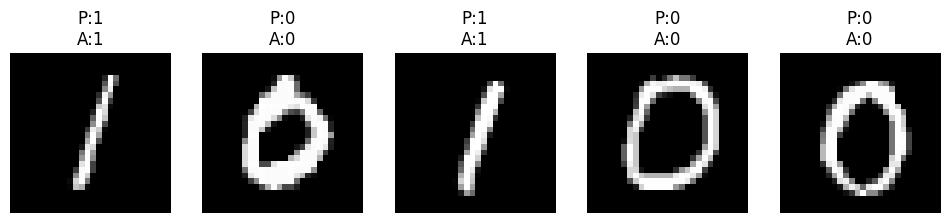

In [28]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):

    axes[i].imshow(images[i].squeeze(), cmap="gray")

    pred = int(predictions[i].item())

    actual = int(labels[i])

    axes[i].set_title(
        f"P:{pred}\nA:{actual}"
    )

    axes[i].axis("off")

plt.show()

In [ ]:
import torch.nn as nn

class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(32 * 7 * 7, 64),

            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [30]:
model = CNNClassifier()

print(model)

CNNClassifier(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [31]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)